# Varible Energy Positron Annihilation Spectroscopy Simulated Example
This notebook contains example on how to use pyPAS in order to do VEPDB\
The example calculate data for simulated sample and then extract it

In [4]:
import numpy as np
import xarray as xr
import pandas as pd

from scipy.constants import nano, micro, centi, pico

import matplotlib.pyplot as plt

from pyPAS.positron_implantation_profile import ghosh_material_parameters, makhov_material_parameters, ghosh_profile, makhov_profile, multilayer_implantation_profile
from pyPAS.positron_annihilation_profile import scipy_profile_solver, annihilation_fraction_per_layer, profile_solver
from pyPAS.sample import Layer, Material, Sample
from pyPAS.vedb import OneBulkDiffusionLengthOptimization

from uncertainties import nominal_value, std_dev, ufloat
from uncertainties.unumpy import uarray



# Cu simulation sample description

In [5]:
cu_diffusion_length = 126 # nano meter
D = 1 * (nano/centi) ** 2 / pico # normal for metals [cm**2/s]


lambda_b = D/cu_diffusion_length**2

m = Material(name='Copper', diffusion=D,mobility=0, bulk_annihilation_rate=lambda_b)

l = Layer(start=0., width=10000, material=m)
absorbtion_length = 1e0
cu_sample = Sample(layers=[l], absorbtion_length=absorbtion_length)

# implantation profile

In [6]:
data_gos = ghosh_material_parameters()
data_mak = makhov_material_parameters()

Cu_parameters = data_mak.iloc[9].copy()
Cu_parameters.loc['density'] = 8.96

In [7]:
implantation_depth = np.linspace(0, cu_sample.sample_length(), 100000)
implantation_energy = np.arange(0.5, 50, 0.5)

In [14]:
positron_implantation_profiles = [xr.DataArray(data=makhov_profile(implantation_depth, energy, Cu_parameters.density, Cu_parameters),
                                                   coords={'x':implantation_depth}) for energy in implantation_energy]

# Solve the equilibrium profile
and then get calculate the simulated s parameter

In [15]:
positron_solved_profiles =  [profile_solver(positron_implantation_profile, cu_sample, mesh_size=20000) for positron_implantation_profile in positron_implantation_profiles]

assume that positron annihilationg in the surface see S=0.53 and positron in the bulk sees S=0.5

In [22]:
s_simulation_per_channel = xr.DataArray([0.53,0.5], coords={'layer':['surface','layer_0']})
s_simulation = [(annihilation_fraction_per_layer(positron_solved_profiles[i], cu_sample)*s_simulation_per_channel).sum('layer').item() for i in range(implantation_energy.size)] 

Text(0, 0.5, 'S Parameter')

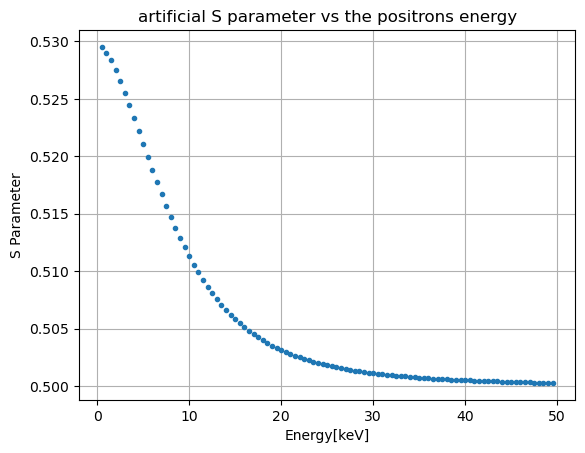

In [23]:
plt.plot(implantation_energy, s_simulation, '.')
plt.title('artificial S parameter vs the positrons energy')
plt.grid(True)
plt.xlabel('Energy[keV]')
plt.ylabel('S Parameter')


# VEDB
Given s_simulation, using PyPAS to extract the simulation diffusion length.

guess a sample

In [25]:
L = 100 # nano meter
D = 1 * (nano/centi) ** 2 / pico # normal for metals [cm**2/s]

lambda_b = D/L**2

m = Material(name='Copper', diffusion=D,mobility=0, bulk_annihilation_rate=lambda_b)

l = Layer(start=0., width=10000, material=m)
cu_absorbtion_length = 1
initial_guess_sample = Sample(layers=[l], absorbtion_length=absorbtion_length)

In [26]:
# calculate the expected implantation profile in the sample
positron_implantation_profiles = [xr.DataArray(data=makhov_profile(implantation_depth, energy, Cu_parameters.density, Cu_parameters),
                                                   coords={'x':implantation_depth}) for energy in implantation_energy]

define vedbfit

In [31]:
vedbfit = OneBulkDiffusionLengthOptimization(positron_implantation_profiles, pd.Series(uarray(s_simulation, np.array(s_simulation)*0.001), implantation_energy), initial_guess_sample)

In [32]:
parm = vedbfit.optimize_diffusion_length(bounds=[0, np.inf])
parm

{'layer_0': 125.91809534432763+/-2.5083617709599944}

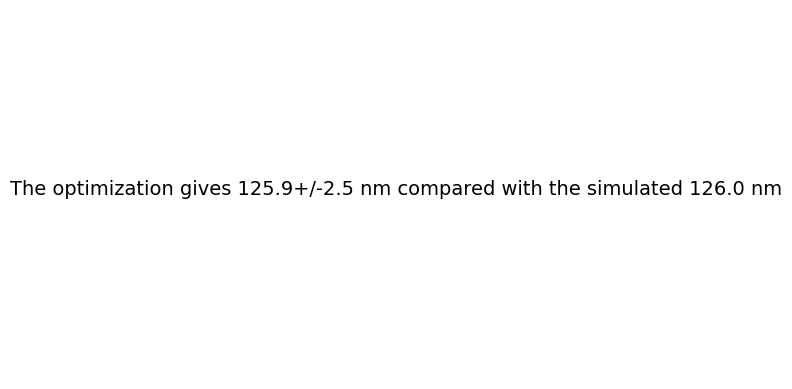

In [41]:
plt.figure()
plt.text(0.5, 0.5,
         f"The optimization gives {parm['layer_0']:.1f} nm compared with the simulated {cu_diffusion_length:.1f} nm",
         fontsize=14,
         ha="center")
plt.axis("off")
plt.show()